# Fase 6: Pré-processamento de Texto 

Este notebook implementa um pipeline completo de limpeza utilizando técnicas de Processamento de Linguagem Natural (NLP) através das bibliotecas `spaCy` e `NLTK`.

Inicialmente, esse pré processamento será feito nas colunas de título e descrição, enquanto não temos a transcrição.

O resultado será armazenado em uma nova coluna chamada `clean_title_description`.

In [76]:
import pandas as pd
from nltk.corpus import stopwords
import nltk
import numpy as np
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
nltk.download('stopwords')
import spacy as sp

project_root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root_path)
from PreProcessing.pre_processing import PreProcessing
from tqdm import tqdm

project_root_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root_path not in sys.path:
    sys.path.append(project_root_path)

[nltk_data] Downloading package stopwords to /home/ester/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [77]:
df = pd.read_csv("../data/complete_dataset.csv")

### Distribuição de Idiomas (Validação do Dataset)

Antes de rodar o pipeline de Processamento de Linguagem Natural (NLP) em português, precisamos garantir que o nosso corpus de texto é, de fato, composto por vídeos na linguagem. 

A API do YouTube nos forneceu a coluna `defaultAudioLanguage`. Abaixo, verificamos a frequência de cada idioma para identificar possíveis ruídos (vídeos estrangeiros) e a quantidade de vídeos sem idioma declarado (`NaN`).

--- Tabela de Idiomas ---


,Quantidade,Percentual (%)
defaultAudioLanguage,,
pt-PT,4839,47.13
pt-BR,3616,35.22
pt,785,7.65
en,395,3.85
en-US,169,1.65
id,104,1.01
hi,90,0.88
es,72,0.70
zxx,26,0.25


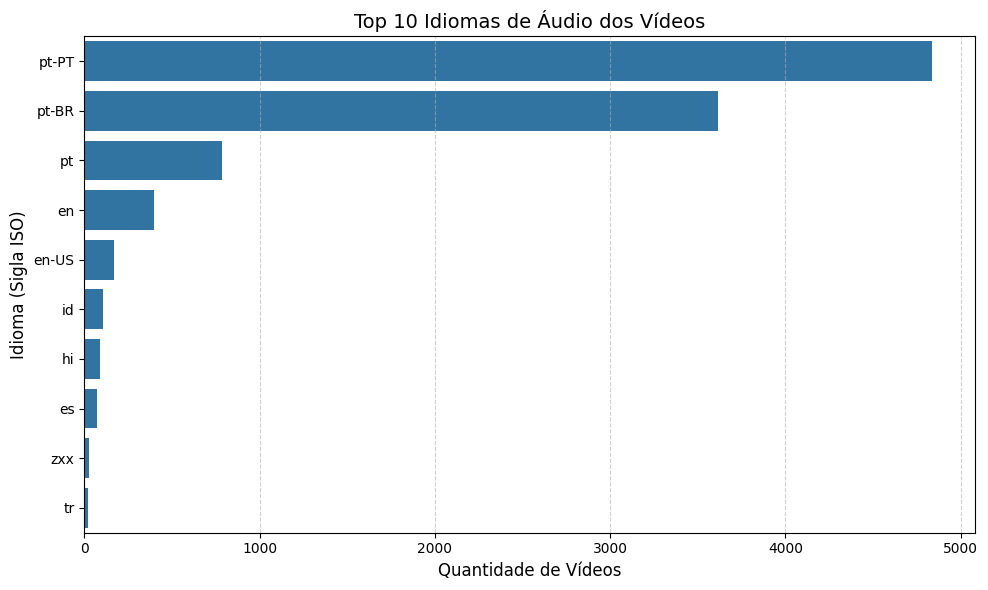

In [78]:
# dropna=False permite ver quantos vídeos vieram com o idioma vazio (NaN)
contagem_idiomas = df['defaultAudioLanguage'].value_counts(dropna=False)
percentual_idiomas = df['defaultAudioLanguage'].value_counts(dropna=False, normalize=True) * 100

df_idiomas = pd.DataFrame({
    'Quantidade': contagem_idiomas,
    'Percentual (%)': percentual_idiomas.round(2)
})

print("--- Tabela de Idiomas ---")
display(df_idiomas)

plt.figure(figsize=(10, 6))

# Pegamos apenas os top 10 idiomas para o gráfico não ficar poluído
top_idiomas = df['defaultAudioLanguage'].fillna('Não Declarado').value_counts().head(10)

sns.barplot(x=top_idiomas.values, y=top_idiomas.index)

plt.title('Top 10 Idiomas de Áudio dos Vídeos', fontsize=14)
plt.xlabel('Quantidade de Vídeos', fontsize=12)
plt.ylabel('Idioma (Sigla ISO)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Esse código abaixo serve para verificar alguns vídeos desses idiomas diferentes.

Alguns vídeos que vieram com idiomas diferentes estão em português. Iremos mantê-los no nosso dataset: 
- 'zxx' significa sem conteúdo linguístico
- As outras que aparecerem são outros idiomas, mas apesar disso alguns vídeos estão em português

Vamos mudar manualmente esses vídeos para português

In [79]:
idiomas_suspeitos = ['zxx', 'ko', 'ru', 'ab', 'sk', 'tw', 'eu', 'akk']

df_gringos = df[df['defaultAudioLanguage'].isin(idiomas_suspeitos)].copy()

df_gringos['url'] = 'https://www.youtube.com/watch?v=' + df_gringos['videoId']

colunas = ['videoId', 'defaultAudioLanguage', 'title', 'channelTitle', 'url']

#display(df_gringos[colunas]) 

Alterando esses vídeos para "pt" e filtrando o dataset apenas para português

In [80]:
ids_confirmados_pt = [
    'WA5EdJkpUjU', 
    '1ujCstU1M0k',
    '3T3jrTUQqgU',
    'R1jkPuRAjxE',
    'JRTtu4ziZXo',
    'hSttvGW3OOQ',
    '20xVXiX4MDI',
    'saQXefQLESs',
    'QB8J493ydB0',
    'DZjkA07DKZg',
    'gVDAWSo9jq8',
    'IvOEQ3F8ey8',
    'QPw5jsM7AlI',
    'edhFSoH31p4',
    'ItclcRHYUtg',
    'tfLQIektzxo',
    'jp7Fv83jIU8',
    'eaDargaMISA',
    'cJIl0UVQ67w',
    'Kk66HUSASTw',
    'I5NEYTeMfrQ',
    'TxaC9ynoy3k',
    'kZd7M8j4-9E',
    '6UWl0uKScRo',
    'RSztkt0Upeg',
    '8yLDHVAel3w',
    'HSQNaVA9u8k',
    'ac82lr7JMVE',
    'JmNTvpqaDFI',
    '-2N4tdfHZvY'
]

df.loc[df['videoId'].isin(ids_confirmados_pt), 'defaultAudioLanguage'] = 'pt'

idiomas_validos = ['pt', 'pt-BR', 'pt-PT']

tamanho_antigo = len(df)

df = df[df['defaultAudioLanguage'].isin(idiomas_validos)].copy()

df.reset_index(drop=True, inplace=True)

tamanho_novo = len(df)
videos_descartados = tamanho_antigo - tamanho_novo

print("--- Filtro de Idioma Aplicado ---")
print(f"Tamanho do dataset antigo: {tamanho_antigo}")
print(f"Vídeos descartados (Gringos/Sem idioma): {videos_descartados}")
print(f"Tamanho final do dataset limpo: {tamanho_novo} vídeos.")


--- Filtro de Idioma Aplicado ---
Tamanho do dataset antigo: 10267
Vídeos descartados (Gringos/Sem idioma): 997
Tamanho final do dataset limpo: 9270 vídeos.


### União das colunas de título e descrição

In [81]:
print("Antes da União")
display(df[['videoId', 'title', 'description']].head(3))

df['title_description'] = df['title'].fillna('') + ' ' + df['description'].fillna('')

print("\nDepois da União (Nova Coluna)")
display(df[['videoId', 'title_description']].head(3))

Antes da União


,videoId,title,description
0,w22lrhGXy_I,FELCA O MELHOR XERIFE DO MM2! #roblox,NaN
1,wpRkmL6Hbbo,Dep Federal Jadyel Alencar estará no Fantástico hoje!,Irá comentar sobre a PL 2628/2022 que trata sobre o Estatuto da criança e adolescente digital qu...
2,ZzrG8BgHoZ0,As primeiras impressões sobre o ECA Digital | Leandro Alvarenga,"O presidente Lula assinou o decreto que oficializa o ECA Digital, nova legislação que visa prote..."



Depois da União (Nova Coluna)


,videoId,title_description
0,w22lrhGXy_I,FELCA O MELHOR XERIFE DO MM2! #roblox
1,wpRkmL6Hbbo,Dep Federal Jadyel Alencar estará no Fantástico hoje! Irá comentar sobre a PL 2628/2022 que trat...
2,ZzrG8BgHoZ0,As primeiras impressões sobre o ECA Digital | Leandro Alvarenga O presidente Lula assinou o decr...


### Pré processamento

In [82]:
def remove_repetion_caracteres(string, max_repetition=2):
    if not string:
        return string
    
    result = string[0]
    count = 1
    
    for i in range(1, len(string)):
        if string[i] == string[i-1]:
            count += 1
            if count <= max_repetition:
                result += string[i]
        else:
            count = 1
            result += string[i]
    
    return result

def preprocess_text_pipeline(#input_csv_path='./data/dataFrame.csv', 
                              #output_csv_path='./data/dataFrame.csv',
                              df,
                              stopwords_file='stopwords.txt',
                              text_column="title_description"):
   
    stem = sp.load("pt_core_news_sm")
    pp = PreProcessing(language="pt")
    
    custom_stopwords = [line.strip() for line in open(stopwords_file, 'r', encoding='utf-8')]
    pt_stopwords = set(stopwords.words('portuguese'))
    
    # Adiciona stopwords à lista da classe PreProcessing
    pp.append_stopwords_list(list(pt_stopwords - set(pp.stopwords)) + custom_stopwords)

    def preprocessing(text):
        if pd.isna(text):
            return np.nan

        tokens = stem(text.lower()) # Processo de lematização da biblioteca spaCy - retorna a lista dos tokens do texto
        text = ' '.join([text for token in tokens for text in token.lemma_.strip().split()]) # Junta estes tokens na ordem do texto bruto
        text = pp.remove_stopwords(text) # Remove stopwords presentes
        text = pp.lowercase_unidecode(text) # Coloca tudo em lowercase e remove acento
        text = pp.remove_stopwords(text) # Remove stopwords presentes 
        text = pp.remove_tweet_marking(text) # Remove @ ou # seguido de 1 ou mais carcteres e n ' ' seguidos
        text = remove_repetion_caracteres(text) # Remove a repetição de caracteres ex: gooool -> gool
        text = pp.remove_urls(text) # Remove http\S+ *, ou seja, qualquer http seguido de 1 ou mais caracteres e os espaços no final
        text = pp.remove_punctuation(text) # Remove os sinais de pontuação e reorganiza os espaços
        text = pp.remove_numbers(text) # Remove os números
        text = pp.remove_n(text, n=3) # Remove palavras de tamanho <= n(n=3)
        
        return text
    
    tqdm.pandas()
    df['clean_title_description'] = df[text_column].progress_apply(preprocessing)

    return df

In [ ]:
df_clean = preprocess_text_pipeline(df=df, text_column='title_description')
display(df_clean)

100%|██████████| 9270/9270 [02:57<00:00, 52.31it/s]


,videoId,title,channelTitle,channelId,publishedAt,description,tags,categoryId,duration,caption,viewCount,likeCount,commentCount,algorithmTopics,madeForKids,defaultAudioLanguage,title_description,clean_title_description
0,w22lrhGXy_I,FELCA O MELHOR XERIFE DO MM2! #roblox,Raivoso1016,UCRmBRNMStx1KTLoXZQB2MZg,2026-02-13T16:01:23Z,NaN,NaN,20,PT27S,False,529995,11403,145,"Action-adventure_game, Video_game_culture",False,pt-BR,FELCA O MELHOR XERIFE DO MM2! #roblox,felcar xerife mmroblox
1,wpRkmL6Hbbo,Dep Federal Jadyel Alencar estará no Fantástico hoje!,DynamicsThePi,UCjnfUt7Dk2wn7jeA74mk5Pw,2025-08-17T17:27:20Z,Irá comentar sobre a PL 2628/2022 que trata sobre o Estatuto da criança e adolescente digital qu...,NaN,22,PT25S,False,176,10,0,"Politics, Society",True,pt-PT,Dep Federal Jadyel Alencar estará no Fantástico hoje! Irá comentar sobre a PL 2628/2022 que trat...,federal jadyel alencar fantastico hoje comentar tratar estatuto crianca adolescente digital entr...
2,ZzrG8BgHoZ0,As primeiras impressões sobre o ECA Digital | Leandro Alvarenga,Olhar Digital,UCGV72aVJuWP0QPNGH4YgIww,2026-03-20T00:30:41Z,"O presidente Lula assinou o decreto que oficializa o ECA Digital, nova legislação que visa prote...","eca digital, eca digital lula, decreto eca digital, proteção de menores na internet, crianças na...",28,PT13M36S,False,2057,48,37,"Society, Technology",False,pt-BR,As primeiras impressões sobre o ECA Digital | Leandro Alvarenga O presidente Lula assinou o decr...,impressao digital leandro alvarengar presidente lula assinar decreto oficializar digital legisla...
3,glr13drvkhE,"Além do tempo, o conteúdo também importa!",Daniel Rufato,UCoJs_0AtX-Bdg9-venJ0IOg,2025-09-18T18:03:30Z,"Além do tempo de tela do seu filho, você precisa olhar também para o conteúdo que seus filhos es...",NaN,22,PT1M12S,False,172,3,0,"Health, Video_game_culture",True,pt-PT,"Além do tempo, o conteúdo também importa! Além do tempo de tela do seu filho, você precisa olhar...",conteudo importar tela filho precisar olhar conteudo filho consumir jogo violencia estimulo agre...
4,pmmwmIJZ5_k,BASEUS WM01 É BOM? O MELHOR CUSTO-BENEFÍCIO EM FONES SEM FIO!Se você busca um TWS que seja discreto,RS Eletrônicos Brasil,UC9W5_DSY-1_22WQBlhDJmsg,2025-10-18T18:16:48Z,"RS ELETRÔNICOS BRASIL | TECNOLOGIA, SEGURANÇA E INOVAÇÃO\n\nBem-vindo ao canal oficial da RS Ele...","#xaiomidelivery, #celularentrega, #realmesorocaba, #realmedelivery, #celular, #iphone, #smartpho...",28,PT24S,False,236,4,1,"Lifestyle_(sociology), Technology",False,pt-PT,BASEUS WM01 É BOM? O MELHOR CUSTO-BENEFÍCIO EM FONES SEM FIO!Se você busca um TWS que seja discr...,baseu wmcusto beneficio fone buscar discreto eletronico brasil tecnologia seguranca inovacao can...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9265,neLALRywe94,Não deixe nada te abalar @felquinhas #react #felca #socialmedia #marketingdigital #reflexao #ads,Felca Cortado,UChFAYaVmYnFJhXXmkADjY3g,2025-11-30T06:49:22Z,Não deixe nada te abalar @felquinhas #react #felca #socialmedia #marketingdigital #reflexao #...,NaN,22,PT18S,False,17867,766,19,NaN,False,pt-PT,Não deixe nada te abalar @felquinhas #react #felca #socialmedia #marketingdigital #reflexao #ads...,deixar abalar react felcar socialmedir marketingdigital reflexao deixar abalar react felcar soci...
9266,MVZZMaJzskU,Teleton 2025 | Vinhetas de Intervalo,Memória Teleton,UC5S7dJ2QxjOg_NKt5ArZ5sQ,2025-11-08T05:14:00Z,__________________________________________________\nFaça parte deste movimento e ajude a transfo...,"Teleton, AACD, SBT, HEBE CAMARGO, SILVIO SANTOS, TONZINHO, NINA",29,PT10S,False,1742,27,4,"Entertainment, Television_program",False,pt,Teleton 2025 | Vinhetas de Intervalo __________________________________________________\nFaça pa...,teleton vinheta intervalo movimento ajude transformar realidade paciente atender aacd teleton ch...
9267,L9WNPGYMPEk,O QUE É ADULTIZAÇÃO? Explicação Simples e Direta!,O que é...?,UCixFJLr8x-Lu8haNyCSXanQ,2025-08-12T17:44:57Z,📌 

OSError: Cannot save file into a non-existent directory: 'data'

In [85]:
df_clean.to_csv("../data/preprocessed_title_description.csv")